# xCounter — Experimento: sensibilidade da taxa de sucesso ao limiar de xG

**Disciplina:** COE609 — Ciência de Dados Aplicada ao Futebol (UFRJ, 2026.1)

Varremos o limiar de xG que define `sucesso` de **0,10** (referência atual) até
**0,00**, de 1% em 1%. O limiar **0,00 equivale a *qualquer chute*** classificar o
contra-ataque como sucesso (`xg_final >= 0` é sempre verdade quando há finalização).

Regra do rótulo: `sucesso = terminou_chute AND (xg_final >= limiar)`.
Como `xg_final` já está no dataset, o recálculo é instantâneo (não reprocessa nada).

In [1]:
import os

# Executa a partir da raiz do projeto (este notebook fica em notebooks/)

if os.path.basename(os.getcwd()) == 'notebooks':

    os.chdir('..')

print('Diretório de trabalho:', os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dados_processados/xcounter_features_unificado.csv', encoding='utf-8')
print(f'{len(df)} contra-ataques | com finalização: {int(df["terminou_chute"].sum())}')

Diretório de trabalho: C:\Users\lolfa\OneDrive\Área de Trabalho\Futebol + DS\COE609-2026.1
642 contra-ataques | com finalização: 221


## 1. Taxa de sucesso por limiar

In [2]:
limiares = [round(x, 2) for x in np.arange(0.10, -0.001, -0.01)]  # 0.10, 0.09, ..., 0.00

linhas = []
for t in limiares:
    suc = df['terminou_chute'] & (df['xg_final'] >= t)
    linhas.append({'limiar_xG': t, 'n_sucessos': int(suc.sum()),
                   'pct_sucesso': round(suc.mean() * 100, 1)})

tab = pd.DataFrame(linhas)
tab['rotulo'] = tab['limiar_xG'].apply(lambda t: 'qualquer chute' if t == 0.0 else f'{t:.2f}')
display(tab[['rotulo', 'limiar_xG', 'n_sucessos', 'pct_sucesso']])

,rotulo,limiar_xG,n_sucessos,pct_sucesso
0,0.10,0.10,97,15.1
1,0.09,0.09,105,16.4
2,0.08,0.08,117,18.2
3,0.07,0.07,129,20.1
4,0.06,0.06,142,22.1
5,0.05,0.05,158,24.6
6,0.04,0.04,177,27.6
7,0.03,0.03,195,30.4
8,0.02,0.02,209,32.6
9,0.01,0.01,219,34.1


## 2. Evolução da % de sucesso conforme o limiar desce

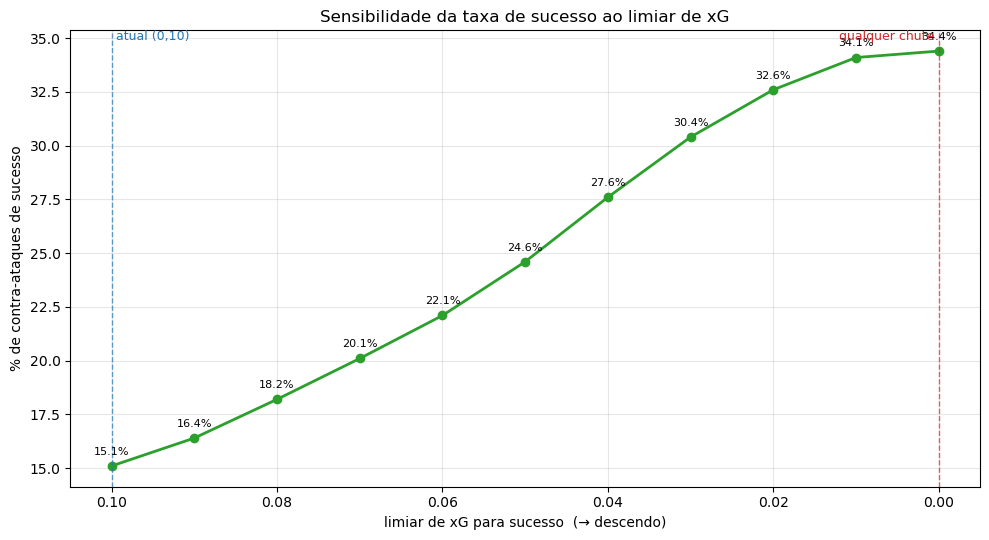

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(tab['limiar_xG'], tab['pct_sucesso'], marker='o', color='#2ca02c', lw=2)

# anota cada ponto
for _, r in tab.iterrows():
    ax.annotate(f"{r['pct_sucesso']:.1f}%", (r['limiar_xG'], r['pct_sucesso']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

# destaca referência (0.10) e 'qualquer chute' (0.00)
ax.axvline(0.10, color='#1f77b4', ls='--', lw=1, alpha=0.7)
ax.text(0.10, ax.get_ylim()[1], ' atual (0,10)', color='#1f77b4', va='top', fontsize=9)
ax.axvline(0.00, color='#d62728', ls='--', lw=1, alpha=0.7)
ax.text(0.00, ax.get_ylim()[1], 'qualquer chute ', color='#d62728', va='top', ha='right', fontsize=9)

ax.invert_xaxis()  # limiar descendo da esquerda p/ direita
ax.set_xlabel('limiar de xG para sucesso  (→ descendo)')
ax.set_ylabel('% de contra-ataques de sucesso')
ax.set_title('Sensibilidade da taxa de sucesso ao limiar de xG')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Leitura

- Quanto **menor** o limiar, **mais** contra-ataques contam como sucesso (alvo menos
  desbalanceado), mas o critério fica mais frouxo (chutes de baixa qualidade entram).
- O patamar em **0,00** é a taxa de cadeias que **terminam em qualquer finalização**.
- A escolha do limiar é um trade-off entre **balanceamento do alvo** e **rigor da
  definição de sucesso** — afeta diretamente a modelagem.